# Assignment 5

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

Additional notes:

* Please note that in this assignment, students are expected to work independently. As a result, no two solutions should look identical in terms of coding;
* You may import any libraries you need to complete the assignment. However, you must implement the model using TensorFlow (do not use PyTorch);
* Follow the same steps/idea as in Assignment 4; the difference here is that you extend a logistic model to more than two classes;
* <span style="color:chocolate"> Focus on the execution of the task rather than model performance </span> (this is how the TA will grade your work);
* Even though the prediction performance for your chosen outcome is low, it doesn't necessarily mean there is something wrong with your implementation. It could also be that the data is not supportive enough for your prediction task... again, focus on the learning opportunity and not the numbers you get;
* Your instructional team has extensive experience developing and running ML models. Often, we encounter situations where a model doesn't perform well on a predictive task. This can happen due to the nature of the data or the need for significant tweaking of variables to achieve good results;
* Do not spend significantly more time on this task than you did on Assignment 4, unless you wish to experiment and learn more.
---

``Objective``
* Perform multiclass classification using logistic regression. <span style="color:chocolate"> You will choose the outcome of interest. </span>

``Motivation``
* Chocolate is one of the most popular candies in the world. Each year, residents of the United States collectively eat more than 2.8 billions pounds (Source: Kaggle). However, not all chocolate bars are created equal! In this assignment, you will have the opportunity to delve into the world of chocolate by choosing your own machine learning task. 


``Data``

* The [Chocolate Bar dataset](https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings) contains expert ratings of 1,795 individual chocolate bars, along with information on their regional origin, percentage of cocoa, the variety of chocolate bean used and where the beans were grown (Source: Kaggle).

### Import libraries

In [55]:
%reset -f
from __future__ import print_function

import math
import numpy as np
import numpy.linalg as nla
import pandas as pd
import re
import six
from os.path import join
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from keras_tuner import HyperParameters

# feel free to import other libraries as needed

import warnings
warnings.filterwarnings('ignore')

In [56]:
import sys
print(sys.executable)

/Users/LeahFinger/anaconda3/envs/tf-env/bin/python


### Define functions

In [57]:
def read_data():
    ''''''
    # Read data
    df = pd.read_csv(
        "https://download.mlcc.google.com/mledu-datasets/flavors_of_cacao.csv",
        sep=",",
        encoding='latin-1'
    )
    
    return df

In [58]:
def clean_data(df):
    ''''''
    # Set the output display to have one digit for decimal places and limit it to
    # printing 15 rows.
    pd.options.display.float_format = '{:.2f}'.format
    pd.options.display.max_rows = 15
    
    # Rename the columns.
    df.columns = [
        'maker', 'specific_origin', 'reference_number',
        'review_date', 'cocoa_percent', 'maker_location',
        'rating', 'bean_type', 'broad_origin'
    ]

    # df.dtypes

    # Replace empty/null values with "Blend"
    df['bean_type'] = df['bean_type'].fillna('Blend')

    # Cast bean_type to string to remove leading 'u'
    df['bean_type'] = df['bean_type'].astype(str)
    df['cocoa_percent'] = df['cocoa_percent'].str.strip('%')
    df['cocoa_percent'] = pd.to_numeric(df['cocoa_percent'])

    # Correct spelling mistakes, and replace city with country name
    df['maker_location'] = df['maker_location']\
    .str.replace('Amsterdam', 'Holland')\
    .str.replace('U.K.', 'England')\
    .str.replace('Niacragua', 'Nicaragua')\
    .str.replace('Domincan Republic', 'Dominican Republic')

    # Adding this so that Holland and Netherlands map to the same country.
    df['maker_location'] = df['maker_location']\
    .str.replace('Holland', 'Netherlands')

    def cleanup_spelling_abbrev(text):
        replacements = [
            ['-', ', '], ['/ ', ', '], ['/', ', '], ['\(', ', '], [' and', ', '], [' &', ', '], ['\)', ''],
            ['Dom Rep|DR|Domin Rep|Dominican Rep,|Domincan Republic', 'Dominican Republic'],
            ['Mad,|Mad$', 'Madagascar, '],
            ['PNG', 'Papua New Guinea, '],
            ['Guat,|Guat$', 'Guatemala, '],
            ['Ven,|Ven$|Venez,|Venez$', 'Venezuela, '],
            ['Ecu,|Ecu$|Ecuad,|Ecuad$', 'Ecuador, '],
            ['Nic,|Nic$', 'Nicaragua, '],
            ['Cost Rica', 'Costa Rica'],
            ['Mex,|Mex$', 'Mexico, '],
            ['Jam,|Jam$', 'Jamaica, '],
            ['Haw,|Haw$', 'Hawaii, '],
            ['Gre,|Gre$', 'Grenada, '],
            ['Tri,|Tri$', 'Trinidad, '],
            ['C Am', 'Central America'],
            ['S America', 'South America'],
            [', $', ''], [',  ', ', '], [', ,', ', '], ['\xa0', ' '],[',\s+', ','],
            [' Bali', ',Bali']
        ]
        for i, j in replacements:
            text = re.sub(i, j, text)
        return text

    df['specific_origin'] = df['specific_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Cast specific_origin to string
    df['specific_origin'] = df['specific_origin'].astype(str)

    # Replace null-valued fields with the same value as for specific_origin
    df['broad_origin'] = df['broad_origin'].fillna(df['specific_origin'])

    # Clean up spelling mistakes and deal with abbreviations
    df['broad_origin'] = df['broad_origin'].str.replace('.', '').apply(cleanup_spelling_abbrev)

    # Change 'Trinitario, Criollo' to "Criollo, Trinitario"
    # Check with df['bean_type'].unique()
    df.loc[df['bean_type'].isin(['Trinitario, Criollo']),'bean_type'] = "Criollo, Trinitario"
    # Confirm with df[df['bean_type'].isin(['Trinitario, Criollo'])]

    # Fix chocolate maker names
    df.loc[df['maker']=='Shattel','maker'] = 'Shattell'
    df['maker'] = df['maker'].str.replace(u'Na\xef\xbf\xbdve','Naive')

    return df

---
### Step 1: Data ingestion

First, we'll initiate the process of discovering the chocolate world by loading the data. Then, to assist with this assignment, we'll start by tidying up the data a little bit. This involves renaming columns and conducting some string preprocessing tasks, which will be handled by the <span style="color:chocolate">clean_data()</span> function mentioned earlier.

In [59]:
df = clean_data(read_data())
print('Shape of data', df.shape)
df.head()

Shape of data (1795, 9)


,maker,specific_origin,reference_number,review_date,cocoa_percent,maker_location,rating,bean_type,broad_origin
0,A. Morin,Agua Grande,1876,2016,63.00,France,3.75,Blend,Sao Tome
1,A. Morin,Kpime,1676,2015,70.00,France,2.75,Blend,Togo
2,A. Morin,Atsane,1676,2015,70.00,France,3.00,Blend,Togo
3,A. Morin,Akata,1680,2015,70.00,France,3.50,Blend,Togo
4,A. Morin,Quilla,1704,2015,70.00,France,3.50,Blend,Peru


### <span style="color:chocolate">Exercise 1:</span> Getting to know the data (5 points)

Answer the following questions:
    
1. How many columns does the dataset contain?
2. How many rows are there in the dataset?
3. What are the column names?
4. List the number of unique values for each column in the data;
5. What are the unique cocoa_percent values?

In [60]:
print(f"1. Number of columns: {df.shape[1]}")
print(f"2. Number of rows: {df.shape[0]}")
print(f"3. Column names: {df.columns}")
print(f"4. Number of unique vals each column in data: {df.nunique()}")
print(f"5. Unique cocoa_percent values: {df.cocoa_percent.value_counts()}")

1. Number of columns: 9
2. Number of rows: 1795
3. Column names: Index(['maker', 'specific_origin', 'reference_number', 'review_date',
       'cocoa_percent', 'maker_location', 'rating', 'bean_type',
       'broad_origin'],
      dtype='object')
4. Number of unique vals each column in data: maker                414
specific_origin     1038
reference_number     440
review_date           12
cocoa_percent         45
maker_location        58
rating                13
bean_type             39
broad_origin         160
dtype: int64
5. Unique cocoa_percent values: cocoa_percent
70.00    672
75.00    222
72.00    189
65.00     78
80.00     72
        ... 
79.00      1
86.00      1
50.00      1
42.00      1
87.00      1
Name: count, Length: 45, dtype: int64


### <span style="color:chocolate">Exercise 2:</span> Choosing the prediction task (5 points)

Now that you’ve explored the data, choose a multiclass outcome (anything except "ratings") that you’re interested in predicting. Note: The outcome should have <span style="color:chocolate">at least 3 classes</span>!

If your chosen outcome variable requires preprocessing, go ahead and handle that below. For instance, you might choose to predict "cocoa_percent". Discretizing it into "0=low," "1=medium," and "2=high" makes it easier to work with/interpret the results.

Your answer here: Cocoa Percent categorized into low=0, medium=1, high=2

In [61]:
print(f"Cocoa_percent min: {df.cocoa_percent.min()}, cocoa_percent max: {df.cocoa_percent.max()}")
print(100-42)
print(58/3)
print(f"Logic will be categorizing cocoa_percent_output to be percentages in dataset broken into 3 numerically equal proportions. \n \
      Note some classes will likely be larger than others- dataset will be imbalanced. 0 Equals low cocoa_percent, 1 equals \n \
      medium cocoa_percent, 2 equals high cocoa_percent.")
df["cocoa_percent_outcome"] = np.where(df["cocoa_percent"] < (42+19), 0, 
                                      np.where(df["cocoa_percent"] < (42+ 19*2), 1,
                                               2))
df.cocoa_percent_outcome.value_counts()

Cocoa_percent min: 42.0, cocoa_percent max: 100.0
58
19.333333333333332
Logic will be categorizing cocoa_percent_output to be percentages in dataset broken into 3 numerically equal proportions. 
       Note some classes will likely be larger than others- dataset will be imbalanced. 0 Equals low cocoa_percent, 1 equals 
       medium cocoa_percent, 2 equals high cocoa_percent.


cocoa_percent_outcome
1    1537
2     183
0      75
Name: count, dtype: int64

---
### Step 2: Data preprocessing

### <span style="color:chocolate">Exercise 3:</span> Prepare data for modeling (20 points)

Following the format of previous assignments, adhere to the following steps as a minimum:

1. Shuffle the dataset;
2. Create training, validation, and test datasets using a 60/20/20 split;
3. Identify the features of interest;
4. Perform necessary cleaning and standarization on the features.

In [62]:
np.random.seed(0)
df = df.copy()
df = df.reset_index(drop=True)
indices = list(range(len(df)))

shuffled_indices = np.random.permutation(indices)

df = df.reindex(shuffled_indices)
print(f"Y = cocoa_percent_outcome, X will be all other variables except Y and ones I have reviewed and think have too many \n \
      categories to be helpful for predicting our cocoa_percent_outcome.")
Y = df["cocoa_percent_outcome"]
X = df.drop(["cocoa_percent_outcome", "cocoa_percent"], axis=1)
print(f"After seeing how manuy caatogories are in specific origin, maker, maker location, and broad origin, I will also drop these variables.")
X = X.drop(["specific_origin", "broad_origin", "maker_location", "maker"], axis=1)


X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size = .4, random_state=1234 )
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=.2, random_state=1234 )

# standardize and get dummies

X_train_dummy= pd.get_dummies(X_train, columns=["bean_type"], drop_first=True)
X_val_dummy = pd.get_dummies(X_val, columns=["bean_type"], drop_first=True)
X_test_dummy = pd.get_dummies(X_test, columns=["bean_type"], drop_first=True)

#Keep same shape (dummy cols) in X val and X test
X_val_dummy = X_val_dummy.reindex(columns=X_train_dummy.columns, fill_value=0)
X_test_dummy = X_test_dummy.reindex(columns=X_train_dummy.columns, fill_value=0)

from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()

num_cols=["reference_number", "review_date", "rating"]
X_train_std = pd.DataFrame(sc_x.fit_transform(X_train[num_cols]),columns=num_cols, index=X_train.index)
X_val_std = pd.DataFrame(sc_x.fit_transform(X_val[num_cols]),columns=num_cols, index=X_val.index)
X_test_std = pd.DataFrame(sc_x.fit_transform(X_test[num_cols]),columns=num_cols, index=X_test.index)

#X_val_dummy = X_val_dummy.reindex(columns=X_val_dummy.columns, fill_value=0)
#X_test_dummy = X_test_dummy.reindex(columns=X_test_dummy.columns, fill_value=0)

X_train_std = pd.concat([X_train_std, X_train_dummy],axis=1)
X_val_std = pd.concat([X_val_std, X_val_dummy],axis=1)
X_test_std = pd.concat([X_test_std, X_test_dummy],axis=1)

print(X_train_std.shape)
print(X_val_std.shape)
print(X_test_std.shape)

X_train_std = np.array(X_train_std, dtype="float32")
X_val_std = np.array(X_val_std, dtype="float32")
X_test_std = np.array(X_test_std, dtype="float32")
Y_train = Y_train.to_numpy()
Y_test = Y_test.to_numpy()

Y = cocoa_percent_outcome, X will be all other variables except Y and ones I have reviewed and think have too many 
       categories to be helpful for predicting our cocoa_percent_outcome.
After seeing how manuy caatogories are in specific origin, maker, maker location, and broad origin, I will also drop these variables.
(1077, 35)
(574, 35)
(144, 35)


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 4:</span> Plots (20 points)

In line with the structure of previous assignments, execute the following steps:

1. Generate a minimum of 4 plots to investigate features and outcome within the training dataset;
2. Ensure that each plot includes clear axis labels and titles;
3. Provide commentary on the insights learned from your visualizations.

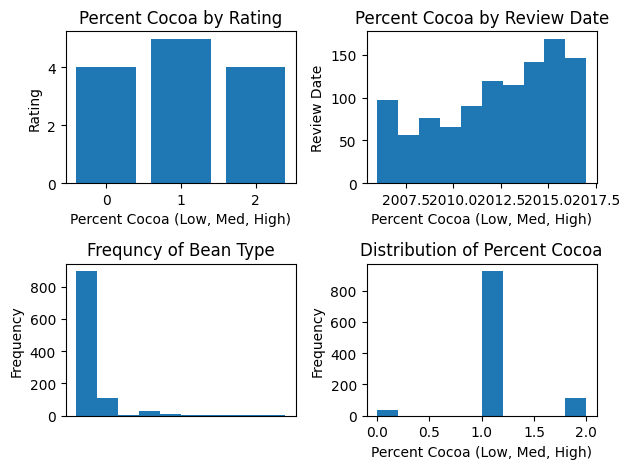

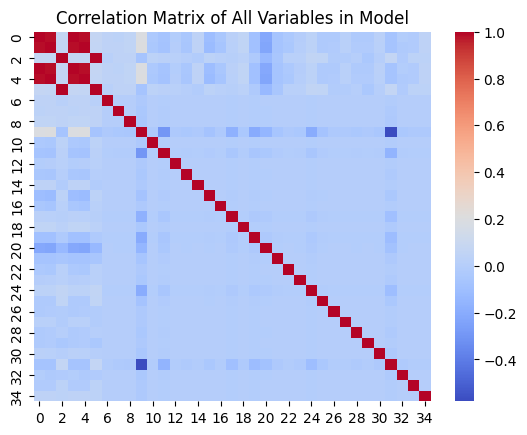

The visualizations have made me think I will drop other high category variables from x train such as 
        specific origin and broad origin, maker, maker location, etc. Including these variables in my model would require 
       lots of dummy variables and that simply feels like it could overload my model. I dropped these from X_train, X_test, 
       and X_val above in my code. In my correlation matrix of standardized and dummy variables,it is hard to interpret 
       because most of my variables are text and when I standardize and create dummies, you lose readability. 
       It appears that most of my variables, by looking at the large light blue sections of corr matrix, that most variables 
       in my data set are just not very correlated with the outcome variable, cocoa percentage. This could make modeling tough.
       I used unstandardized and non dummy variables in my histograms (origninal X_train) and graphs to make them easier to 
       interpret. There aren't really m

In [63]:
import seaborn as sns

fig, axes = plt.subplots(2,2)
axes[0][0].bar( Y_train, X_train["rating"])
axes[0][0].set_title("Percent Cocoa by Rating")
axes[0][0].set_xlabel("Percent Cocoa (Low, Med, High)")
axes[0][0].set_ylabel("Rating")
axes[0][1].hist(X_train["review_date"])
axes[0][1].set_title("Percent Cocoa by Review Date")
axes[0][1].set_xlabel("Percent Cocoa (Low, Med, High)")
#axes[0][1].get_yaxis().set_visible(False)
axes[0][1].set_ylabel("Review Date")
axes[1][0].hist(X_train["bean_type"])
axes[1][0].set_title("Frequncy of Bean Type")
axes[1][0].set_xlabel("Bean Type Distribution")
axes[1][0].get_xaxis().set_visible(False)
axes[1][0].set_ylabel("Frequency")
axes[1][1].hist(Y_train)
axes[1][1].set_title("Distribution of Percent Cocoa")
axes[1][1].set_xlabel("Percent Cocoa (Low, Med, High)")
#axes[1][1].get_yaxis().set_visible(False)
axes[1][1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

df_for_corr_matrix = pd.concat([pd.DataFrame(X_train_std), pd.DataFrame(Y_train)])
correlation_matrix = df_for_corr_matrix.corr()
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of All Variables in Model")
plt.show()

print(f"The visualizations have made me think I will drop other high category variables from x train such as \n \
       specific origin and broad origin, maker, maker location, etc. Including these variables in my model would require \n \
      lots of dummy variables and that simply feels like it could overload my model. I dropped these from X_train, X_test, \n \
      and X_val above in my code. In my correlation matrix of standardized and dummy variables,it is hard to interpret \n \
      because most of my variables are text and when I standardize and create dummies, you lose readability. \n \
      It appears that most of my variables, by looking at the large light blue sections of corr matrix, that most variables \n \
      in my data set are just not very correlated with the outcome variable, cocoa percentage. This could make modeling tough.\n \
      I used unstandardized and non dummy variables in my histograms (origninal X_train) and graphs to make them easier to \n \
      interpret. There aren't really many helpful patterns in the correlation matrix or histograms and graphs. Ratings is the \n \
      only variable that seems to offer us a hint about possible cocoa percent- medium (1) cocoa percent chocolate gets rated \n \
      the highest.")



---
### Step 4: Modeling

### <span style="color:chocolate">Exercise 5:</span> Baseline model (10 points)

When dealing with classification problems, a simple baseline is to select the *majority* class (the most common label in the training set) and use it as the prediction for all inputs.

1. Implement this baseline and report the accuracy metric on the train data;

2. Implement a function that computes the Log Loss (cross-entropy loss) metric and use it to evaluate this baseline on both the train and validation data. Note: reflect on what you know about the original distribution of classes in your training data (Hint: see Assignment 4 - Exercise 8 and ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example).

In [64]:
def predict_baseline(outcomevar):
    return max([sum(outcomevar==0),sum(outcomevar==1), sum(outcomevar==2) ])/len(outcomevar)

def log_loss(dataset):
    return -1/(len(dataset)) * sum(dataset * np.log(0.8) + (1-dataset)*np.log(1-0.8))

print(f"Majority class classifier baseline model accuracy: {predict_baseline(Y_train)}")
print(f"Log loss of majority class claissifier baseline model: {log_loss(Y_train)}")

Majority class classifier baseline model accuracy: 0.8597957288765088
Log loss of majority class claissifier baseline model: 0.1291793095669932


In [65]:
type(X_train_std)

numpy.ndarray

In [66]:
type(X_val_std)


numpy.ndarray

### <span style="color:chocolate">Exercise 6:</span> Improvement over baseline with Tensorflow (10 points)

Use TensorFlow (TF) to train a multiclass logistic regression model much like you did in Assignment 4. The goal here is to build a ML model to improve over the baseline classifier. You have the flexibility to choose which features to include.

With this in mind, complete the following tasks:

1. Build and compile a multiclass classification TF model (call it model_tf). Hint: the activation function, the loss, and the evaluation metric are different compared to the binary logistic regression (see ``Module Demos/05 Multiclass Logistic Regression.ipynb`` in bCourses for an example). Set learning_rate = 0.0001 and optimizer = SGD.
2. Train model_tf using the training dataset and pass the validation data for validation. Set num_epochs = 10 and batch_size = 32.
3. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

If instructions for any other hyperparameters are not provided here, you are free to select your own or use the default settings.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Output (Dense)                  │ (None, 3)              │           108 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108 (432.00 B)

 Trainable params: 108 (432.00 B)

 Non-trainable params: 0 (0.00 B)

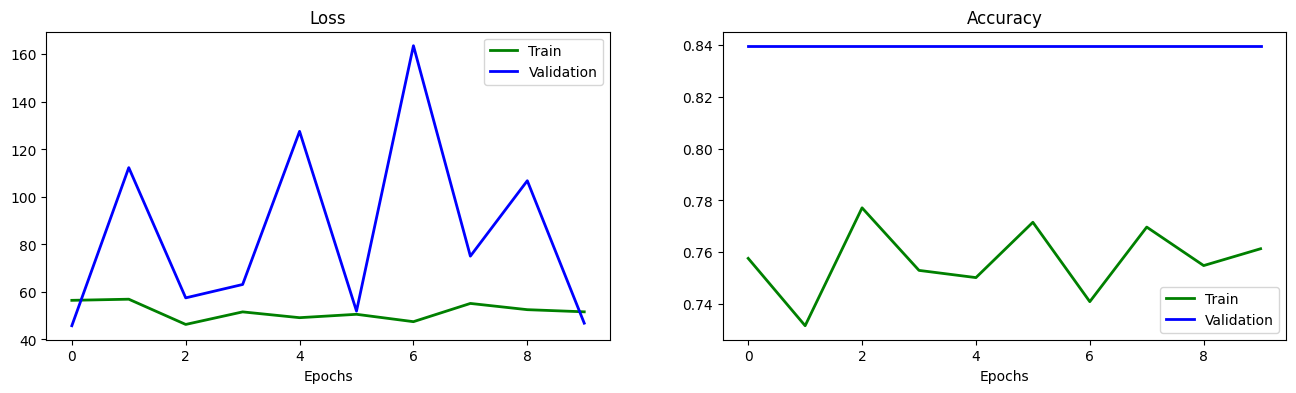

In [67]:
from tensorflow import keras
from tensorflow.keras import initializers

def build_model(num_features):
    """Return a simple logistic regression model using the Keras Sequential API."""
  # Clear session and set a random seed for consistent behavior.
    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)
    

  # Use Keras Sequential API to build a logistic regression
    model = keras.Sequential()
    
    # create input layer
    model.add(tf.keras.Input(shape=(num_features,), name='Input'))
    
    
    # create output layer
    model.add(keras.layers.Dense(
          units=3,  # remember it's a multiclass classification problem
          use_bias=True,
          activation='softmax', # remember it's a multiclass classification problem
          kernel_initializer=initializers.RandomNormal(stddev=0.01),
          bias_initializer=initializers.RandomNormal(stddev=0.01),
          name='Output'
    ))
  
  # Use Categorical Crossentropy as our loss and the SGD optimizer.
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001),
        metrics=['accuracy']
    )
    return model

# Build a model
model_tf = build_model(num_features=X_train_std.shape[1])
model_tf.summary()

tf.random.set_seed(1234)
np.random.seed(1234)
# Train model
hist= model_tf.fit(x=X_train_std,
                y=Y_train,
                validation_data=[X_val_std, Y_val],
                batch_size=32,
                epochs=10,
                verbose=0 #silence fit
)

# grab history
history = hist.history

# plot loss for train and validation
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history['loss'], lw=2, color='green')
plt.plot(history['val_loss'], lw=2, color='blue')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Loss');

# plot accuracy for train and validation
ax = fig.add_subplot(1, 2, 2)
plt.plot(history['accuracy'], lw=2, color='green')
plt.plot(history['val_accuracy'], lw=2, color='blue')
plt.legend(['Train', 'Validation'], fontsize=10)
ax.set_xlabel('Epochs', size=10)
ax.set_title('Accuracy');

In [68]:
len(X_train)

1077

---
### Step 5: Hyperparameter tuning

### <span style="color:chocolate">Exercise 7:</span> Choosing hyperparameters (10 points)

1. Fine-tune the **learning rate**, **number of epochs**, and **batch size** hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various values for these hyperparameters. Hint: you can manually test different hyperparameter values or you can use the [Keras Tuner](https://www.tensorflow.org/tutorials/keras/keras_tuner). 

After identifying your preferred model configuration, print the following information:

2. The first five learned parameters of the model (this should include the bias term);
3. The loss at the final epoch on both the training and validation datasets;
4. The percentage difference between the losses observed on the training and validation datasets.
5. Compare the training/validation loss of the TensorFlow model (model_tf) with the baseline model's loss. Does the TensorFlow model demonstrate an improvement over the baseline model?

In [69]:
import keras_tuner as kt
def build_model_tuner(hp):
    """Return a simple logistic regression model using the Keras Sequential API."""
  # Clear session and set a random seed for consistent behavior.
    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)
    

  # Use Keras Sequential API to build a logistic regression
    model = keras.Sequential()
    
    # create input layer
    model.add(tf.keras.Input(shape=(X_train_std.shape[1],), name='Input'))
    
    
    # create output layer
    model.add(keras.layers.Dense(
          units=3,  # remember it's a multiclass classification problem
          use_bias=True,
          activation='softmax', # remember it's a multiclass classification problem
          kernel_initializer=initializers.RandomNormal(stddev=0.01),
          bias_initializer=initializers.RandomNormal(stddev=0.01),
          name='Output'
    ))
    # Keras Tuner chooses learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    # Use Categorical Crossentropy as our loss and the SGD optimizer.
    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.SGD(learning_rate=hp_learning_rate),
        metrics=['accuracy']
    )
    return model

tuner = kt.Hyperband(build_model_tuner,
                     objective='val_loss',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt_2')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train_std, Y_train, epochs=50, validation_data=(X_val_std, Y_val),
              callbacks=[stop_early])

best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

model_tuner = tuner.hypermodel.build(best_hps)

# Build a model
model_tuner = build_model(num_features=X_train_std.shape[1])
model_tuner.summary()

tf.random.set_seed(1234)
np.random.seed(1234)
# Train model
hist= model_tuner.fit(x=X_train_std,
                y=Y_train,
                validation_data=[X_val_std, Y_val],
                batch_size=32,
                epochs=10,
                verbose=0 #silence fit
)

# grab history
history_tuner = hist.history

w, b = model_tuner.layers[0].get_weights()

print(f" First 5 feature coefficients: {w[:5]}, Bias term: {b[:]}")
print(f" Loss at final epoch training dataset: {history_tuner['loss'][-1]}") 
print(f" Loss at final epoch validation dataset: {history_tuner['val_loss'][-1]}")
print(f" Percentage point difference training val loss: {history_tuner['loss'][-1] - history_tuner['val_loss'][-1]}")
print(f"Comparing this model to the baseline model, this model is certainly nog better. Loss for baseline model was \n \
      roughly 0.13, this loss is over 50. It seems though this model has been tuned for better parameters, a majority \n \
      class classifier does a much better job of predicting the classes in this model. Probably because the classes are \n \
      imbalanced and my variables do not do a great job of predicting percentage cooca- this is a poorly preforming model.")

Reloading Tuner from my_dir/intro_to_kt_2/tuner0.json


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Output (Dense)                  │ (None, 3)              │           108 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108 (432.00 B)

 Trainable params: 108 (432.00 B)

 Non-trainable params: 0 (0.00 B)

 First 5 feature coefficients: [[-0.00620624 -0.00257275  0.01321086]
 [-0.00312046  0.00415448 -0.01731507]
 [-0.00607508  0.0026626  -0.01208292]
 [ 0.00404523  0.07823694 -0.08740298]
 [ 0.00121216  0.16556787 -0.14671862]], Bias term: [ 0.01289097  0.00121287 -0.01656532]
 Loss at final epoch training dataset: 49.635955810546875
 Loss at final epoch validation dataset: 109.62857818603516
 Percentage point difference training val loss: -59.99262237548828
Comparing this model to the baseline model, this model is certainly nog better. Loss for baseline model was 
       roughly 0.13, this loss is over 50. It seems though this model has been tuned for better parameters, a majority 
       class classifier does a much better job of predicting the classes in this model. Probably because the classes are 
       imbalanced and my variables do not do a great job of predicting percentage cooca- this is a poorly preforming model.


---
### Step 6: Evaluation and generalization

### <span style="color:chocolate">Exercise 8:</span> Compute metrics (10 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate aggregate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras. and the <span style="color:chocolate">np.max()</span> method available in NumPy.

2. Does the model demonstrate strong aggregate generalization capabilities? Provide an explanation based on your accuracy observations.

In [70]:
### print accuracy for training
y_train_pred_tuner = model_tuner.predict(x=X_train_std)

# set predicted label based on highest probability
y_train_maxpred_tuner =  np.argmax(y_train_pred_tuner, axis=1)

print('Train, misclassified examples: %d' % (Y_train != y_train_maxpred_tuner).sum())
error_train_tuner = (Y_train != y_train_maxpred_tuner).sum()/len(y_train_maxpred_tuner)
print('Train, prediction accuracy: %.3f'% (1-error_train_tuner))

### print accuracy for test
y_test_pred_tuner = model_tuner.predict(x=X_test_std)

# set predicted label based on highest probability
y_test_maxpred_tuner =  np.argmax(y_test_pred_tuner, axis=1)

print('Test, misclassified examples: %d' % (Y_test != y_test_maxpred_tuner).sum())
error_test_tuner = (Y_test != y_test_maxpred_tuner).sum()/len(y_test_maxpred_tuner)
print('Test, prediction accuracy: %.3f'% (1-error_test_tuner))

print(f"Based on the difference between training and test prediction accuracy, which is the number of correct predictions out of \n \
      total (total predictions made by our model), the generalization is pretty good for this model because the difference \n \
      between train prediction accuracy and test prediction accuracy is somewhat small and interestingly, the model has higher \n \
      test prediction accuracy than train. Meaning our model does a pretty good job of predicting unseeen data. It does not, \n \
      however, do much better in terms of accuracy than a majority class classifier does. So I have hesistations about \n \
      this model's generalizability- I think most chocolates are medium (1 in our output variable) percent cocoa and the \n \
      model has picked up on that.")

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Train, misclassified examples: 151
Train, prediction accuracy: 0.860
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test, misclassified examples: 15
Test, prediction accuracy: 0.896
Based on the difference between training and test prediction accuracy, which is the number of correct predictions out of 
       total (total predictions made by our model), the generalization is pretty good for this model because the difference 
       between train prediction accuracy and test prediction accuracy is somewhat small and interestingly, the model has higher 
       test prediction accuracy than train. Meaning our model does a pretty good job of predicting unseeen data. It does not, 
       however, do much better in terms of accuracy than a majority class classifier does. So I have hesistations about 
       this model's generalizability- I think most chocolates are medium (1 in our output variable) percent cocoa and the 
       model has picked up on that.


### <span style="color:chocolate">Exercise 9:</span> Additional metrics (10 points)

Using the test dataset:

1. Plot the confusion matrix. Identify which class the model confuses the most.

2. Determine which class has the lowest precision. What is the precision? Which class is the largest source of false positives?

3. Determine which class has the lowest recall. What is the recall? Which class is the largest source of false negatives?

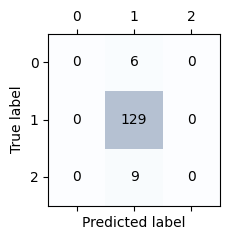

The class that confuses the model the most according to my confusion matrix is 2 classes- 0 or low cocoa percentage and 
      2 or high cooca percentage. This model is just predicting 1 or medium cocoa every time and is right a lot of the time 
       which is very misleading. 
Class-wise precision: [0.         0.89583333 0.        ]
The class with the lowest precision is a tie for 0 and 2 (low and high cocoa). Both have a precision score of 0. 
       It is unfortunate: class 1 is our highest source of false positives because our model is always predicting class 1. So 
       the precision score is 0 in both class 0 and class 2 (low and high cocoa percent, respectiveley) because they are 
       rare in our data set so our model never predicts them. It is important here to look at precision across all three 
       classes because class 1 precision is kind of high but the other 2 classes have terrible precision scores. The worst 
       precision scores you can get.
Class-wise recall

In [71]:
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, average_precision_score

conf_matrix = tf.math.confusion_matrix(
    Y_test,
    y_test_maxpred_tuner,
    num_classes=None,
    weights=None,
    dtype=tf.dtypes.int32,
    name=None
)
conf_matrix

def confusion_matrix_plot(conf_matrix):
    """ Confusion matrix matplotlib plot
    # param conf_matrix: nested list of TP, TN, FP, FN
    # return: None
    """
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center')

    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    plt.tight_layout()
    plt.show()

confusion_matrix_plot(conf_matrix.numpy())

print(f"The class that confuses the model the most according to my confusion matrix is 2 classes- 0 or low cocoa percentage and \n\
      2 or high cooca percentage. This model is just predicting 1 or medium cocoa every time and is right a lot of the time \n \
      which is very misleading. ")

# compute precision and recall for test data, for each class # use sklearn
print("Class-wise precision:", precision_score(Y_test, y_test_maxpred_tuner, average=None))
print(f"The class with the lowest precision is a tie for 0 and 2 (low and high cocoa). Both have a precision score of 0. \n \
      It is unfortunate: class 1 is our highest source of false positives because our model is always predicting class 1. So \n \
      the precision score is 0 in both class 0 and class 2 (low and high cocoa percent, respectiveley) because they are \n \
      rare in our data set so our model never predicts them. It is important here to look at precision across all three \n \
      classes because class 1 precision is kind of high but the other 2 classes have terrible precision scores. The worst \n \
      precision scores you can get.")

print("Class-wise recall:", recall_score(Y_test, y_test_maxpred_tuner, average=None))
print(f"Similar to the precision analysis above, classes 0 and 2 have 0% recall, as they had 0% precision. This is because \n \
      the numerator of recall (and precision) is true positives and this model didn't predict any positives at all for class \n \
      0 and 2 (low and high cooca percent). The recall on class 1 is a perfect 100% because it just predicted 1 every time so it \n \
      didn't miss any 1's in our actual Y_test dataset. The biggest source of false negatives is class 2 because 9 times out of \n \
      all the actual 2s in the datasset we predicted a 1 instead.")


----
#### <span style="color:chocolate">Additional practice question</span> (not graded)

Following the approach in Assignment 4 - Exercise 12, evaluate whether your model shows any signs of unfairness. Explain your findings and propose suggestions for improvement.

In [72]:
# YOUR CODE HERE